# Pipeline evaluation
authors : Lea Carminati, Anthony Miranda

In this notebook, we analyse the performance of our face recognition pipeline. We start by describing the evaluation dataset, then run the full pipeline on the collected test images, and finally compute and interpret the biometric evaluation metrics.

**Note on study design.** This is a deliberate *stress-test* evaluation. The dataset
was built specifically to probe the failure modes of the pipeline: heavy occlusion
(mask, hat), eye visibility, and head pose, rather than to maximise headline accuracy.
The relatively high error rates are therefore expected and intended: the goal is to
characterise **where and why the system degrades**, not to report best-case performance.

In [1]:
import os
import sys
import pickle
from collections import defaultdict, Counter

import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import plotly.express as px
import plotly.graph_objects as go
from tqdm.notebook import tqdm
from IPython.display import Markdown, display

from sklearn.metrics import auc, ConfusionMatrixDisplay, confusion_matrix
from sklearn.preprocessing import StandardScaler

from qdrant_client import QdrantClient
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

from eval_tools import (
    run_pipeline,
    compute_metrics,
    bootstrap_metric,
    tar_at_far,
    get_condition,
    plot_embeddings_3d,
    reduce_3d,
    fetch_db_vectors,
    plot_roc
)

sys.path.append('../fonction/')
from faceDetection import FacesDetects_from_bytes
from faceAlignement2 import align_crop      # versione corretta (allineamento ArcFace + gate frontalità)
# from faceAlignment import align_crop      # vecchia versione, NON usare
from faceEmbeddings import get_embedding
from loadModel import load_model



In [2]:
EVAL_DIR      = "../images/evaluation_set"
UNKNOWN_LABEL = "unknown"
MODEL_PATH    = "../model/blaze_face_short_range.tflite"
THRESHOLD     = np.arange(0.0, 1.0, 0.01)
COLLECTION    = "face"

#client = QdrantClient(host="172.19.89.254", port=6333)
client = QdrantClient(path ="../qdrant_data")
print(client)

base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
options = vision.FaceDetectorOptions(base_options=base_options)
detector = vision.FaceDetector.create_from_options(options)

## Dataset Description

The evaluation dataset is located in the `images/evaluation_set` folder and consists of two main parts:
- **Registered persons (genuine)**: photographs of people already stored in the database, never seen during training.
- **Impostors**: photographs of people who are not present in the database.

Each registered person has a dedicated folder named exactly as their identity in the database. 
Each folder contains photographs of the person under different acquisition conditions: normal, glasses, hat, mask or side.

### File Naming Convention
To enable condition-based analysis, each photograph follows the naming convention:
`<name>_<condition><index>.jpg`
where `<index>` allows multiple photographs per condition (e.g., `lea_glasses1.jpg`, `lea_glasses2.jpg`).

### Data Collection
The dataset was entirely collected by the authors (Lea Carminati and Anthony Miranda). Photographs of registered persons were taken directly by the authors after permission. 
Impostor photographs were sourced from Pexels (https://www.pexels.com), a royalty-free image platform, ensuring legal and ethical use of the data.

Impostor photographs were limited to one image per person, as royalty-free platforms rarely provide several photographs of the same person. This results in **20 impostor attempts** (16 of which are successfully processed), an imbalance with respect to genuine attempts that nevertheless reflects a realistic open-set scenario, where each impostor is typically encountered only once.

In [4]:
people = [p for p in os.listdir(EVAL_DIR) if os.path.isdir(os.path.join(EVAL_DIR, p))]

for person in sorted(people):
    photos = [f for f in os.listdir(os.path.join(EVAL_DIR, person))
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    print(f'{person} : {len(photos)} photos')

total_photos = sum(
    len([f for f in os.listdir(os.path.join(EVAL_DIR, p))
         if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    for p in people
)

genuine_people = [p for p in people if p != UNKNOWN_LABEL]
print(f'\nRegistered persons : {len(genuine_people)}')
print(f'Total photos       : {total_photos}')

anthony miranda : 11 photos
clémentine beaulieu : 11 photos
florient marchal : 11 photos
gabriel viard : 12 photos
kardiatou ba : 12 photos
lea carminati : 11 photos
mathis monnin : 10 photos
robin henry : 10 photos
sasha villemiane : 13 photos
sidney dachez : 12 photos
unknown : 20 photos

Registered persons : 10
Total photos       : 133


## Databse embedding visualisations

Before evaluatin, we inspect the reference embedding stored in Qdrant. The vectors (10 identities) are projected from 512D to 3D with t-SNE (cosine metric, matching the search space). Compact, well-separated clusters per identity indicate that the enrolement embeddings are discriminative.

In [6]:
X_db, y_db = fetch_db_vectors(client, COLLECTION)
print(f"Database : {len(X_db)} vectors, {len(set(y_db))} identities")

# t-SNE with cosine metric, consistent with the ArcFace search space.
# (PCA would also be defensible on such a small set, but t-SNE makes the
# per-identity clusters far easier to inspect visually.)

_ = plot_embeddings_3d(X_db, y_db, method="tsne",
                       title="Database embeddings (registered in Qdrant) t-SNE")


Database : 517 vectors, 10 identities


The porjection shows one dominant cluster per identity, confirming that the embeddings group significantly by person. Some clusters sit close to each other, a first hint of the confusable pairs thath the confusion matrix will expose at the end of this notebook.

## Distribution of acquisition conditions

The evaluation photos are tagged by aquisition condition thought the file-naming convention describes above. Counting them showes how the stress-test design weights the difficult conditions.

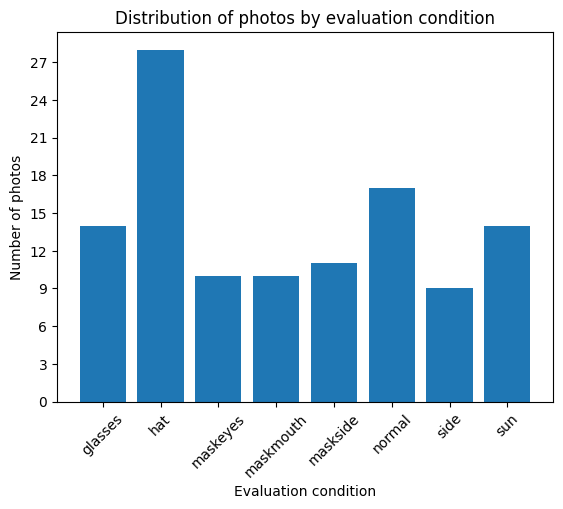

In [9]:
condition_counts = defaultdict(int)
for p in people:
    if p == UNKNOWN_LABEL:
        continue
    for f in os.listdir(os.path.join(EVAL_DIR, p)):
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            condition_counts[get_condition(f)] += 1

plt.bar(condition_counts.keys(), condition_counts.values())
plt.xlabel('Evaluation condition')
plt.xticks(rotation=45)
plt.ylabel('Number of photos')
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.title('Distribution of photos by evaluation condition')
plt.show()

In [12]:

total = sum(condition_counts.values())
n_cond = len(condition_counts)
top_cond = max(condition_counts, key=condition_counts.get)
min_cond = min(condition_counts, key=condition_counts.get)

display(Markdown(f"""
The evaluation set contains **{total} genuine photographs** spread over
**{n_cond} acquisition conditions**. The distribution is intentionally uneven:
**{top_cond}** is the most represented ({condition_counts[top_cond]} photos)
while **{min_cond}** is the least ({condition_counts[min_cond]} photos).
This imbalance is a direct consequence of the stress-test design, harder
conditions are oversampled to probe failure modes rather than to balance classes.
"""))


The evaluation set contains **113 genuine photographs** spread over
**8 acquisition conditions**. The distribution is intentionally uneven:
**hat** is the most represented (28 photos)
while **side** is the least (9 photos).
This imbalance is a direct consequence of the stress-test design, harder
conditions are oversampled to probe failure modes rather than to balance classes.


## Pipeline Execution

We now run the full recognition pipeline on every image in the evaluation dataset.
For each photograph, the following four steps are applied sequentially:

1. **Face Detection** (MediaPipe BlazeFace): detects the face in the image and returns a bounding box.
2. **Alignment and Crop** (`align_crop`): crops and normalizes the detected face eyes are aligned and the image is resized to a fixed dimension.
3. **Embedding extraction** (ArcFace): encodes the cropped face into a fixed-size feature vector in a metric space.
4. **Vector search** (Qdrant, cosine similarity): queries the database to find the closest stored identity and returns a similarity score and the predicted name. If no match is found, the identity is labelled `unknown`.

Each processed image is stored as a dictionary in the `results` list with the following fields:

| Field | Description |
|---|---|
| `label_true` | Ground truth identity (folder name) |
| `predicted_name` | Identity predicted by the system |
| `score` | Cosine similarity score returned by Qdrant |
| `is_genuine` | `True` if the person is registered in the database, `False` if impostor |
| `photo` | Filename of the image |

Images where no face is detected are skipped and reported.

In [13]:

results = []
failures = []   
arcface_model = load_model("arcface", True)

for person_name in tqdm(os.listdir(EVAL_DIR)):
    person_dir = os.path.join(EVAL_DIR, person_name)
    if not os.path.isdir(person_dir):
        continue
    is_genuine = person_name != UNKNOWN_LABEL
    for img_name in os.listdir(person_dir):
        if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        img_path = os.path.join(person_dir, img_name)
        with open(img_path, 'rb') as f:
            image_bytes = f.read()

        result = run_pipeline(
            image_bytes, detector, client, COLLECTION,
            label_true=person_name, is_genuine=is_genuine,
            align_crop_fn=align_crop, get_embedding_fn=get_embedding,
            FacesDetects_fn=FacesDetects_from_bytes,
            arcface_model=arcface_model
        )

        result['photo'] = img_name

        if result['status'] == 'ok':
            results.append(result)
        else:
            failures.append(result)     

genuine_results  = [r for r in results if r['is_genuine']]
impostor_results = [r for r in results if not r['is_genuine']]

# ── breakdown of failures by reason ──
reasons = Counter(f['status'] for f in failures)

print(f'Total processed (ok) : {len(results)}')
print(f'  Genuine            : {len(genuine_results)}')
print(f'  Impostors          : {len(impostor_results)}')
print(f'  Failures (discarded): {len(failures)}')
for reason, n in reasons.most_common():
    print(f'      {reason:20s}: {n}')

# Detailed list of discarded photos, grouped by reason
print('\nDiscarded photos detail:')
for reason in reasons:
    photos = [f['photo'] for f in failures if f['status'] == reason]
    print(f'  [{reason}] {photos}')

[ModelLoader] ArcFace chargé sur GPU


c:\Users\Dell\Desktop\Reconnaissance-Faciale-Projet-Dell-Technologies\.venv\lib\site-packages\onnxruntime\capi\onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


  0%|          | 0/12 [00:00<?, ?it/s]

Total processed (ok) : 105
  Genuine            : 89
  Impostors          : 16
  Failures (discarded): 28
      rejected_alignment  : 24
      no_detection        : 4

Discarded photos detail:
  [no_detection] ['anthony_maskeyes1.jpg', 'ka_maskside1.jpg', 'lea_hat4.jpg', 'unknown7.jpg']
  [rejected_alignment] ['anthony_side2.jpg', 'clem_hat2.jpg', 'flo_glasses2.jpg', 'gabriel_glasses2.jpg', 'gabriel_hat3.jpg', 'gabriel_side1.jpg', 'ka_glasses1.jpg', 'ka_hat1.jpg', 'ka_side1.jpg', 'ka_side2.jpg', 'lea_normal2.jpg', 'lea_side1.jpg', 'mathis_side1.jpg', 'mathis_sun2.jpg', 'robin_hat2.jpg', 'sasha_glasses2.jpg', 'sasha_hat3.jpg', 'sasha_normal2.jpg', 'sasha_sun2.jpg', 'sid_hat2.jpeg', 'sid_side1.jpeg', 'unknown2.jpg', 'unknown4.jpg', 'unknown5.jpg']


## Detection failure analysis

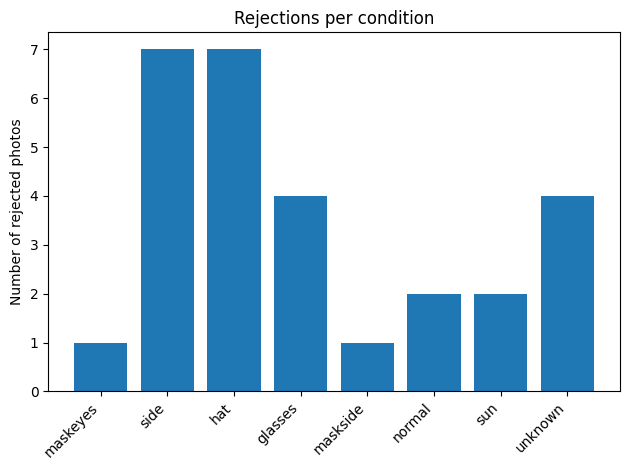

In [14]:


# 'failures' now holds dicts; the filename is stored in f['photo']
failures_by_condition = defaultdict(int)
for f in failures:
    failures_by_condition[get_condition(f['photo'])] += 1

plt.bar(failures_by_condition.keys(), failures_by_condition.values())
plt.ylabel("Number of rejected photos")
plt.title("Rejections per condition")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [16]:

reason_counts = Counter(f['status'] for f in failures)
fail_by_cond = Counter(get_condition(f['photo']) for f in failures)
worst = fail_by_cond.most_common(2)
worst_txt = ", ".join(f"**{c}** ({n})" for c, n in worst)

display(Markdown(f"""
Out of all attempts, **{len(failures)} photographs were discarded before matching**.
Breaking this down by cause: """ + ", ".join(f"`{k}` = {v}" for k, v in reason_counts.items()) + f""".
The conditions producing the most discards are {worst_txt}.

Two distinct mechanisms are at play. **`no_detection`** means MediaPipe BlazeFace
found no face at all, typically when landmarks (eyes, nose, mouth) are occluded by
a mask or hat. **`rejected_alignment`** means a face *was* detected but discarded by
the frontality gate (`_YAW_MAX`), which removes strong profiles where half the face
is invisible and alignment to the ArcFace template would be unreliable. The latter is
a deliberate design choice, not a failure of the model.
"""))


Out of all attempts, **28 photographs were discarded before matching**.
Breaking this down by cause: `no_detection` = 4, `rejected_alignment` = 24.
The conditions producing the most discards are **side** (7), **hat** (7).

Two distinct mechanisms are at play. **`no_detection`** means MediaPipe BlazeFace
found no face at all, typically when landmarks (eyes, nose, mouth) are occluded by
a mask or hat. **`rejected_alignment`** means a face *was* detected but discarded by
the frontality gate (`_YAW_MAX`), which removes strong profiles where half the face
is invisible and alignment to the ArcFace template would be unreliable. The latter is
a deliberate design choice, not a failure of the model.


## Genuine and impostor score distribution analysis

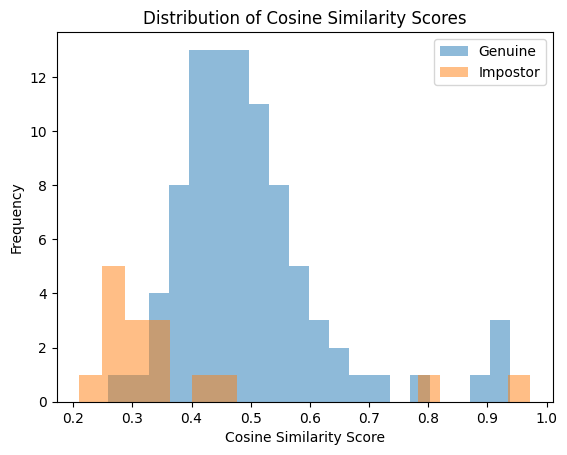

In [17]:
plt.hist([r["score"] for r in genuine_results], bins=20, alpha=0.5, label="Genuine")
plt.hist([r["score"] for r in impostor_results], bins=20, alpha=0.5, label="Impostor")
plt.xlabel("Cosine Similarity Score")   
plt.ylabel("Frequency")
plt.title("Distribution of Cosine Similarity Scores")
plt.legend()
plt.show()

In [19]:
g = np.array([r["score"] for r in genuine_results])
imp = np.array([r["score"] for r in impostor_results])

display(Markdown(f"""
The histogram shows the cosine similarity scores for **genuine** ({len(g)} attempts,
mean {g.mean():.2f}) and **impostor** ({len(imp)} attempts, mean {imp.mean():.2f})
comparisons.

The genuine distribution is **bimodal**: a high cluster (scores ≳ 0.9) corresponds to
easy, frontal, well-lit captures, while a larger cluster around **{np.median(g):.2f}**
gathers the difficult conditions (mask, hat, partial occlusion). Crucially, this lower
genuine cluster **overlaps the impostor scores** in the 0.3–0.5 range and this overlap
is precisely what drives the high EER: no single threshold can cleanly separate the two
populations.
"""))


The histogram shows the cosine similarity scores for **genuine** (89 attempts,
mean 0.50) and **impostor** (16 attempts, mean 0.38)
comparisons.

The genuine distribution is **bimodal**: a high cluster (scores ≳ 0.9) corresponds to
easy, frontal, well-lit captures, while a larger cluster around **0.47**
gathers the difficult conditions (mask, hat, partial occlusion). Crucially, this lower
genuine cluster **overlaps the impostor scores** in the 0.3–0.5 range and this overlap
is precisely what drives the high EER: no single threshold can cleanly separate the two
populations.


## Biometric evaluation metrics

To evaluate the performance of the recognition pipeline, we use the standard biometric metrics defined in the ISO/IEC 19795 norm.


- TAR (True Acceptance Rate): 
$$\text{TAR} = \frac{\text{genuine correctly accepted}}{\text{total genuine}}$$

- FAR (False Acceptance Rate):
$$\text{FAR} = \frac{\text{impostor incorrectly accepted}}{\text{total impostors}}$$


- FRR ( False Reject Rate):
$$\text{FRR} = \frac{\text{genuine incorrectly rejected}}{\text{total genuine}}$$

- ERR (Equal Error Ratio):
The EER is the operating point where FAR and FRR are equal. It is a threshold-independent metric that summarizes the intrinsic discriminative capacity of the system.

$$\tau^* = \arg\min_\tau |\text{FAR}(\tau) - \text{FRR}(\tau)|$$

$$\text{EER} \approx \frac{\text{FAR}(\tau^*) + \text{FRR}(\tau^*)}{2}$$

A lower EER indicates a better system, a perfect system would have EER = 0%.

In [20]:
m = compute_metrics(genuine_results, impostor_results, THRESHOLD)

print(f'EER           : {m["eer_value"]*100:.2f}%')
print(f'EER threshold : {m["eer_threshold"]:.2f}')
print(f'TAR at EER    : {m["tar"][m["eer_idx"]]*100:.2f}%')
print(f'AUC (ROC)     : {m["auc"]:.4f}')

EER           : 25.98%
EER threshold : 0.36
TAR at EER    : 73.03%
AUC (ROC)     : 0.6380


## Statistical uncertainty: bootstrap confidence intervals

Our evaluation set is deliberately small and stress-oriented: 16 successfully processed impostor attempts and a limited number of genuine attempts per
challenging condition. With so few samples, a single point estimate such as "EER = 26%" can be misleading, a slightly different set of impostors could
have produced a noticeably different value.

To quantify this uncertainty we use **bootstrap resampling**. The idea: our observed results are our best available estimate of the underlying population, so resampling from them (with replacement) imitates collecting alternative samples we could have gathered. We resample the genuine and impostor groups **separately**, keeping each
group size fixed, recompute the metric on each synthetic sample, and repeat 1000 times.
The 2.5th and 97.5th percentiles of the resulting distribution give a 95% confidence
interval.

A wide interval is itself a finding: it tells us how much our conclusions are limited
by sample size, rather than hiding that limitation behind a falsely precise number.

EER :  26.0%   95% CI [18.9%, 43.2%]
AUC : 0.638    95% CI [0.489, 0.774]


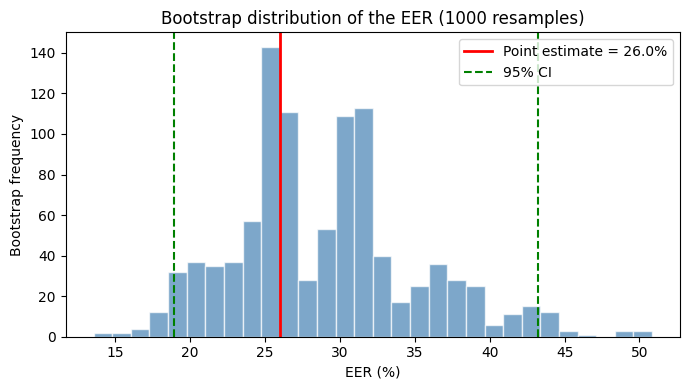

In [21]:

b_eer = bootstrap_metric(genuine_results, impostor_results, THRESHOLD, "eer_value")
b_auc = bootstrap_metric(genuine_results, impostor_results, THRESHOLD, "auc")

print(f'EER : {b_eer["point"]*100:5.1f}%   95% CI [{b_eer["ci_low"]*100:.1f}%, {b_eer["ci_high"]*100:.1f}%]')
print(f'AUC : {b_auc["point"]:.3f}    95% CI [{b_auc["ci_low"]:.3f}, {b_auc["ci_high"]:.3f}]')

# visualizzazione della distribuzione bootstrap dell'EER
plt.figure(figsize=(7, 4))
plt.hist(b_eer["values"] * 100, bins=30, color='steelblue', alpha=0.7, edgecolor='white')
plt.axvline(b_eer["point"] * 100, color='red', lw=2, label=f'Point estimate = {b_eer["point"]*100:.1f}%')
plt.axvline(b_eer["ci_low"] * 100, color='green', ls='--', lw=1.5, label='95% CI')
plt.axvline(b_eer["ci_high"] * 100, color='green', ls='--', lw=1.5)
plt.xlabel('EER (%)')
plt.ylabel('Bootstrap frequency')
plt.title('Bootstrap distribution of the EER (1000 resamples)')
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
eer   = m["eer_value"]; thr = m["eer_threshold"]
tar_e = m["tar"][m["eer_idx"]]; auc_v = m["auc"]
lo, hi = b_eer["ci_low"], b_eer["ci_high"]
alo, ahi = b_auc["ci_low"], b_auc["ci_high"]

display(Markdown(f"""
At its EER operating point the system reaches an **EER of {eer*100:.1f}%**
(threshold **{thr:.2f}**), a **True Accept Rate of {tar_e*100:.0f}%**, and an
**AUC of {auc_v:.3f}**, above the 0.5 random baseline, so the pipeline does carry
real discriminative information.

The headline figure must be read together with its uncertainty. Bootstrap resampling
(B=1000) gives a **95% confidence interval of [{lo*100:.0f}%, {hi*100:.0f}%]** for the
EER and **[{alo:.2f}, {ahi:.2f}]** for the AUC. These intervals are wide because the
evaluation set is small and deliberately hard: the point estimate of {eer*100:.0f}%
alone would overstate how precisely we can pin down performance. The wide band is not
a weakness of the method but an honest reflection of the sample size, and reporting it
is what makes the {eer*100:.0f}% defensible rather than misleading.

> *Methodological note:* the operating threshold is derived from the EER point on this
> same evaluation set. A fully rigorous protocol would fix the threshold on a separate
> validation split; with the present sample size we report the in-sample threshold and
> flag this as a known optimistic bias.
"""))


At its EER operating point the system reaches an **EER of 26.0%**
(threshold **0.36**), a **True Accept Rate of 73%**, and an
**AUC of 0.638** — above the 0.5 random baseline, so the pipeline does carry
real discriminative information.

The headline figure must be read together with its uncertainty. Bootstrap resampling
(B=1000) gives a **95% confidence interval of [19%, 43%]** for the
EER and **[0.49, 0.77]** for the AUC. These intervals are wide because the
evaluation set is small and deliberately hard: the point estimate of 26%
alone would overstate how precisely we can pin down performance. The wide band is not
a weakness of the method but an honest reflection of the sample size, and reporting it
is what makes the 26% defensible rather than misleading.

> *Methodological note:* the operating threshold is derived from the EER point on this
> same evaluation set. A fully rigorous protocol would fix the threshold on a separate
> validation split; with the present sample size we report the in-sample threshold and
> flag this as a known optimistic bias.


In [23]:
for target in (0.10, 0.01, 0.001):
    res = tar_at_far(m, THRESHOLD, target)
    if res is None:
        print(f"FAR <= {target*100:>4.1f}%  : not reachable with this grid")
    else:
        print(f"TAR @ FAR<={target*100:>4.1f}%  : {res['tar']*100:5.1f}%  "
              f"(threshold {res['threshold']:.2f}, actual FAR {res['far']*100:.2f}%)")

TAR @ FAR<=10.0%  :   0.0%  (threshold 0.82, actual FAR 6.25%)
TAR @ FAR<= 1.0%  :   0.0%  (threshold 0.98, actual FAR 0.00%)
TAR @ FAR<= 0.1%  :   0.0%  (threshold 0.98, actual FAR 0.00%)


The result is stark: **TAR = 0% at every FAR budget**. This is a direct consequence of the impostor sample size, not of the matcher alone. With 16 successfully processed impostor attempts, FAR moves in steps of ≈ 6.2%; the threshold that first satisfies the FAR ≤ 10% budget is **0.82**, which sits above almost every genuine score (the bulk of the genuine distribution lies between 0.3 and 0.7 under the stress conditions), so no genuine attempt is accepted there. In other words, on this dataset there is no operating point that is both secure and usable, which is precisely the failure mode this stress-test was designed to expose. The LFW benchmark (`evaluation_LFW.ipynb`) shows that with clean data the same pipeline reaches a TAR of 88% at FAR ≤ 1%.

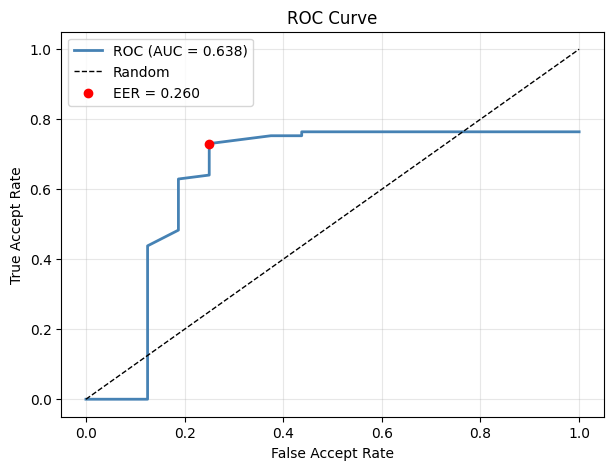

In [24]:
plot_roc(m)

In [25]:

display(Markdown(f"""
The ROC curve plots True Accept Rate against False Accept Rate as the threshold varies.
The curve sits **above the diagonal** (random baseline), with **AUC = {m['auc']:.3f}**,
confirming the system separates genuine from impostor better than chance. The red dot
marks the EER point, where FAR = FRR ≈ {m['eer_value']*100:.0f}%.

The staircase shape is a direct artefact of the small impostor set: with only
{len(impostor_results)} impostor attempts, FAR can only move in steps of
1/{len(impostor_results)} ≈ {100/len(impostor_results):.1f}%, so the curve jumps rather
than rising smoothly. A larger impostor set would smooth it and tighten the AUC estimate.
"""))


The ROC curve plots True Accept Rate against False Accept Rate as the threshold varies.
The curve sits **above the diagonal** (random baseline), with **AUC = 0.638**,
confirming the system separates genuine from impostor better than chance. The red dot
marks the EER point, where FAR = FRR ≈ 26%.

The staircase shape is a direct artefact of the small impostor set: with only
16 impostor attempts, FAR can only move in steps of
1/16 ≈ 6.2%, so the curve jumps rather
than rising smoothly. A larger impostor set would smooth it and tighten the AUC estimate.


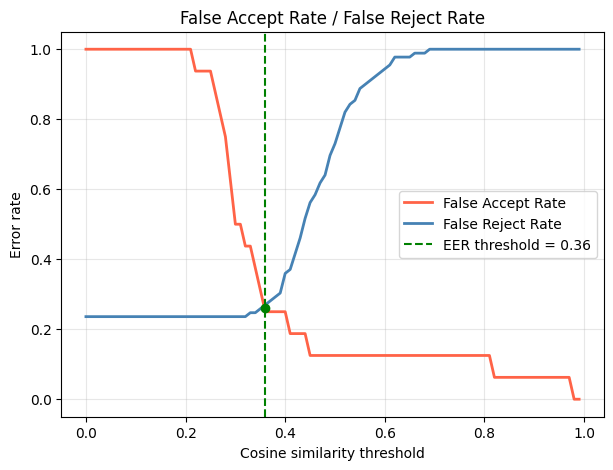

In [26]:
plt.figure(figsize=(7, 5))
plt.plot(THRESHOLD, m['far'], color='tomato',    lw=2, label='False Accept Rate')
plt.plot(THRESHOLD, m['frr'], color='steelblue', lw=2, label='False Reject Rate')
plt.axvline(m['eer_threshold'], color='green', linestyle='--', lw=1.5,
            label=f'EER threshold = {m["eer_threshold"]:.2f}')
plt.scatter(m['eer_threshold'], m['eer_value'], color='green', zorder=5)
plt.xlabel('Cosine similarity threshold')
plt.ylabel('Error rate')
plt.title('False Accept Rate / False Reject Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [27]:

display(Markdown(f"""
This plot shows the **threshold trade-off**: as the cosine threshold rises, the False
Accept Rate (red) falls, fewer impostors slip through, while the False Reject Rate
(blue) climbs, as more genuine users get rejected. The two curves cross at
**threshold = {m['eer_threshold']:.2f}**, defining the EER point where both errors are
balanced at ≈ {m['eer_value']*100:.0f}%.

The choice of threshold is application-driven: a security-critical deployment would
push it higher (accept more false rejections to block impostors), while a
convenience-oriented one would lower it. The EER point is simply the neutral reference
where neither error is favoured.
"""))


This plot shows the **threshold trade-off**: as the cosine threshold rises, the False
Accept Rate (red) falls, fewer impostors slip through, while the False Reject Rate
(blue) climbs, as more genuine users get rejected. The two curves cross at
**threshold = 0.36**, defining the EER point where both errors are
balanced at ≈ 26%.

The choice of threshold is application-driven: a security-critical deployment would
push it higher (accept more false rejections to block impostors), while a
convenience-oriented one would lower it. The EER point is simply the neutral reference
where neither error is favoured.


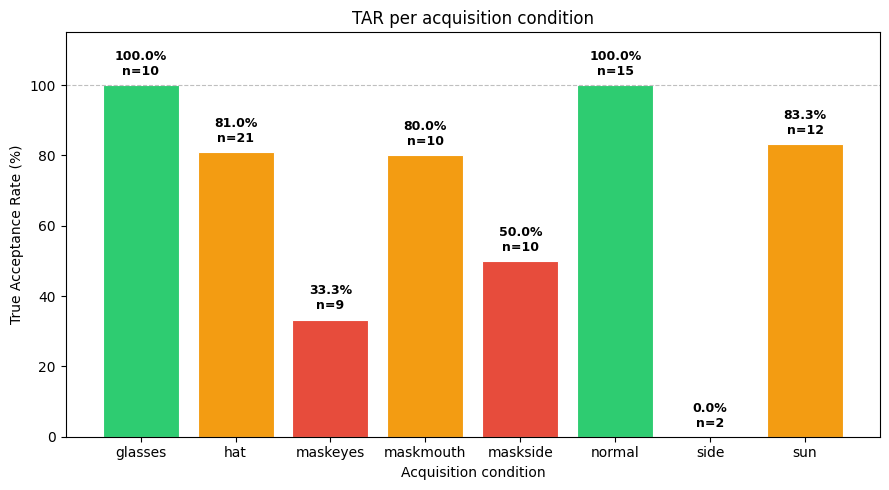

In [28]:
by_condition = defaultdict(list)
for r in genuine_results:
    by_condition[get_condition(r['photo'])].append(r)

conditions = sorted(by_condition.keys())
tar_values = [sum(1 for r in by_condition[c] if r['predicted_name'] == r['label_true'])
              / len(by_condition[c]) * 100 for c in conditions]
n_values   = [len(by_condition[c]) for c in conditions]

colors = ['#2ecc71' if t >= 90 else '#f39c12' if t >= 60 else '#e74c3c' for t in tar_values]

plt.figure(figsize=(9, 5))
bars = plt.bar(conditions, tar_values, color=colors, edgecolor='white', linewidth=0.8)
plt.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.ylim(0, 115)
plt.ylabel('True Acceptance Rate (%)')
plt.xlabel('Acquisition condition')
plt.title('TAR per acquisition condition')
for bar, val, n in zip(bars, tar_values, n_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{val:.1f}%\nn={n}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

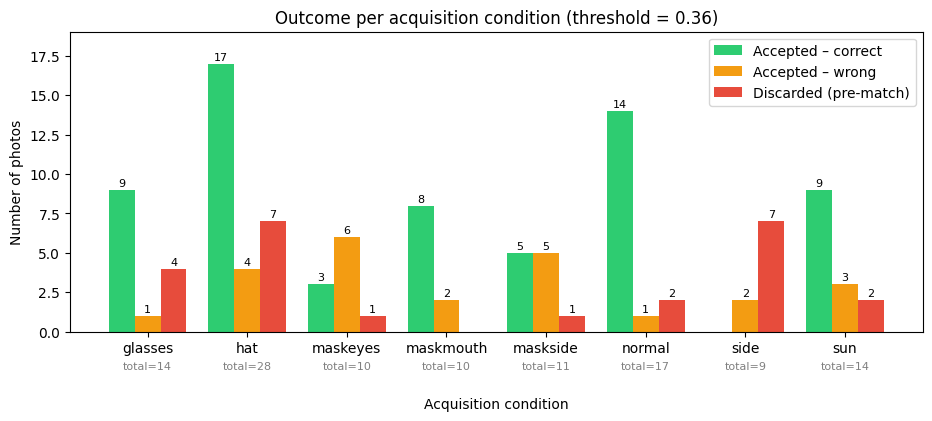

In [29]:

# Threshold from the EER operating point (cell 20 must have run -> 'm' exists)
THR = m["eer_threshold"]

# Three outcomes per condition, computed over ALL genuine photos
# (accepted + discarded), so nothing is hidden:
#   - correct  : reached the match, right identity AND score >= threshold
#   - wrong    : reached the match, but wrong identity OR score below threshold
#   - discarded: never reached the match (no_detection / rejected_alignment)
buckets = defaultdict(lambda: {"correct": 0, "wrong": 0, "discarded": 0})

# Accepted photos (status == "ok") -> split into correct / wrong using the threshold
for r in genuine_results:
    cond = get_condition(r['photo'])
    if r['predicted_name'] == r['label_true'] and r['score'] >= THR:
        buckets[cond]["correct"] += 1
    else:
        buckets[cond]["wrong"] += 1

# Discarded photos (failures) -> only the genuine ones (a real person, not "unknown")
for f in failures:
    if f.get('is_genuine', True):
        cond = get_condition(f['photo'])
        buckets[cond]["discarded"] += 1

conditions = sorted(buckets.keys())
correct   = np.array([buckets[c]["correct"]   for c in conditions])
wrong     = np.array([buckets[c]["wrong"]     for c in conditions])
discarded = np.array([buckets[c]["discarded"] for c in conditions])
totals    = correct + wrong + discarded

x = np.arange(len(conditions))
w = 0.26   # bar width; three side-by-side bars per condition

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w, correct,   w, label='Accepted – correct',     color='#2ecc71')
b2 = ax.bar(x,     wrong,     w, label='Accepted – wrong',       color='#f39c12')
b3 = ax.bar(x + w, discarded, w, label='Discarded (pre-match)',  color='#e74c3c')

# Count on top of each bar
for bars in (b1, b2, b3):
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.1,
                    f'{int(h)}', ha='center', va='bottom', fontsize=8)

# Total below each group, placed BELOW the tick labels.
# x in data coords, y in axes coords (y=-0.18 -> well under the axis).
ax.set_xticks(x)
ax.set_xticklabels(conditions)

trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
for xi, tot in zip(x, totals):
    ax.text(xi, -0.10, f'total={tot}', transform=trans,
            ha='center', va='top', fontsize=8, color='gray')

ax.set_ylabel('Number of photos')
ax.set_xlabel('Acquisition condition', labelpad=30) # push xlabel down to make room
ax.set_title(f'Outcome per acquisition condition (threshold = {THR:.2f})')
ax.legend()
ax.margins(y=0.12)
plt.subplots_adjust(bottom=0.28)   # reserve space at the bottom for the totals
plt.show()

In [30]:
# Reuse the 'buckets' computed in the outcome chart cell above
rows = []
for c in sorted(buckets.keys()):
    b = buckets[c]; tot = b["correct"] + b["wrong"] + b["discarded"]
    acc = b["correct"]/tot*100 if tot else 0
    rows.append((c, acc, b["correct"], b["wrong"], b["discarded"], tot))

best  = max(rows, key=lambda r: r[1])
worst = min(rows, key=lambda r: r[1])

display(Markdown(f"""
Breaking results down by acquisition condition (at threshold {m['eer_threshold']:.2f})
separates the easy cases from the hard ones. Each photo falls into one of three outcomes:
**accepted-correct** (right identity above threshold), **accepted-wrong** (reached the
match but wrong identity or below threshold), or **discarded** (rejected before matching).

Performance is strongly condition-dependent: **{best[0]}** is handled best
({best[1]:.0f}% correct) while **{worst[0]}** is the hardest ({worst[1]:.0f}% correct).
Conditions involving occlusion or pose (mask, side) accumulate both wrong matches and
pre-match discards, whereas frontal, unoccluded captures (normal, glasses) are almost
entirely correct. This confirms that the aggregate EER is pulled up by a minority of
deliberately difficult conditions, not by uniform weakness across the board.
"""))


Breaking results down by acquisition condition (at threshold 0.36)
separates the easy cases from the hard ones. Each photo falls into one of three outcomes:
**accepted-correct** (right identity above threshold), **accepted-wrong** (reached the
match but wrong identity or below threshold), or **discarded** (rejected before matching).

Performance is strongly condition-dependent: **normal** is handled best
(82% correct) while **side** is the hardest (0% correct).
Conditions involving occlusion or pose (mask, side) accumulate both wrong matches and
pre-match discards, whereas frontal, unoccluded captures (normal, glasses) are almost
entirely correct. This confirms that the aggregate EER is pulled up by a minority of
deliberately difficult conditions, not by uniform weakness across the board.


## Confusion matrix

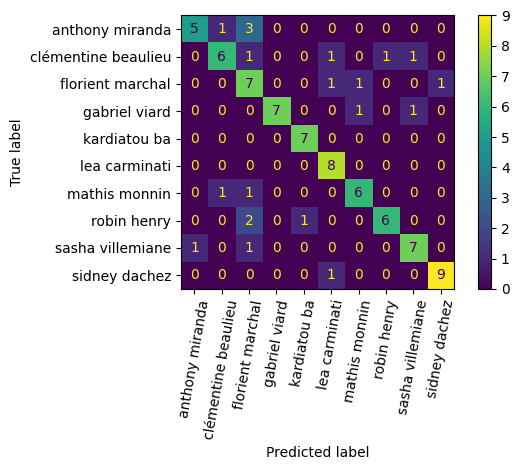

In [31]:
labels = sorted(set(r['label_true'] for r in genuine_results if r['label_true'] != 'unknown'))
y_true = [r['label_true'] for r in genuine_results]
y_pred = [r['predicted_name'] for r in genuine_results]
cm = confusion_matrix(y_true, y_pred, labels=labels)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(xticks_rotation=80)
plt.tight_layout()
plt.show()

In [34]:

# Extract the most confused identity pairs automatically from the matrix
off = cm.copy()
np.fill_diagonal(off, 0)
pairs = []
for i in range(len(labels)):
    for j in range(len(labels)):
        if off[i, j] > 0:
            pairs.append((labels[i], labels[j], off[i, j]))
pairs.sort(key=lambda x: -x[2])

diag = np.trace(cm); total = cm.sum()
top = pairs[:3]
top_txt = "; ".join(f"**{t}** mistaken for **{p}** ({n}×)" for t, p, n in top) if top else "none"

display(Markdown(f"""
The confusion matrix reports identification outcomes per person (without the threshold:
it shows which identity won the nearest-neighbour search). The strong diagonal
({diag}/{total} correct) confirms that most identities are recognised reliably.

The off-diagonal entries reveal the **confusable pairs**: {top_txt}. These are not random
errors, they indicate identities whose ArcFace embeddings lie close in vector space,
often reciprocally (if A is confused with B, B tends to be confused with A). Such pairs
are the natural targets for improvement: more enrolment images per person, or a
discriminative classifier (e.g. SVM) on top of the embeddings, would help separate them.
"""))


The confusion matrix reports identification outcomes per person (without the threshold:
it shows which identity won the nearest-neighbour search). The strong diagonal
(68/89 correct) confirms that most identities are recognised reliably.

The off-diagonal entries reveal the **confusable pairs**: **anthony miranda** mistaken for **florient marchal** (3×); **robin henry** mistaken for **florient marchal** (2×); **anthony miranda** mistaken for **clémentine beaulieu** (1×). These are not random
errors, they indicate identities whose ArcFace embeddings lie close in vector space,
often reciprocally (if A is confused with B, B tends to be confused with A). Such pairs
are the natural targets for improvement: more enrolment images per person, or a
discriminative classifier (e.g. SVM) on top of the embeddings, would help separate them.


## Export results

The raw per-attempt results (genuine, impostor, failures) are serialised to
`results_custom.pkl` so that `comparaison.ipynb` can recompute every metric on
the exact same data, with the same code path as the LFW benchmark.

In [35]:
with open('results_custom.pkl', 'wb') as f:
    pickle.dump({'genuine': genuine_results, 'impostor': impostor_results, 'failures': failures}, f)

## Conclusion

On this deliberately hard evaluation set, the pipeline reaches an **EER of 26.0%**
(95% CI [18.9%, 43.2%]) with an AUC of 0.638 — above chance, but still far from
usable as-is in degraded conditions. The breakdown by acquisition condition shows
that the aggregate figure is driven by a minority of conditions: frontal, unoccluded
captures are handled almost perfectly, while *side* poses and *mask* occlusion
concentrate both pre-match discards and wrong matches. The confusion matrix adds
that residual identification errors are not random but concentrated in a few
confusable identity pairs.

Whether these numbers reflect a flaw in the pipeline or the intrinsic difficulty
of the data cannot be decided from this notebook alone: that is the role of the
LFW benchmark (`evaluation_LFW.ipynb`) and of the side-by-side analysis in
`comparaison.ipynb`.